<a href="https://www.kaggle.com/code/rishabhbhartiya/cytodiffusion-blood-cell-anomaly-detection?scriptVersionId=318153718" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from IPython.display import Javascript
Javascript("""
var cells = Jupyter.notebook.get_cells();
cells.forEach(function(cell) {
    cell.input.hide();
});
""")

<IPython.core.display.Javascript object>

Model,Task,Score,Source
CytoDiffusion,Anomaly Detection (AUC),0.990,Nature Machine Intelligence 2025
Vision Transformer (ViT),Anomaly Detection (AUC),0.916,Baseline
CytoDiffusion,Domain Shift Accuracy,0.854,Nature Machine Intelligence 2025
Discriminative CNN,Domain Shift Accuracy,0.738,Baseline
CytoDiffusion,Low-Data Balanced Accuracy,0.962,Nature Machine Intelligence 2025
Discriminative CNN,Low-Data Balanced Accuracy,0.924,Baseline
CytoDiffusion,Blast Detection Sensitivity,0.905,Nature Machine Intelligence 2025
CytoDiffusion,Blast Detection Specificity,0.962,Nature Machine Intelligence 2025
Human Expert (avg),Synthetic Image Authenticity,0.523,"10 expert haematologists, up to 34 yrs experience"
CytoDiffusion,Standard Classification Accuracy,0.985,Nature Machine Intelligence 2025

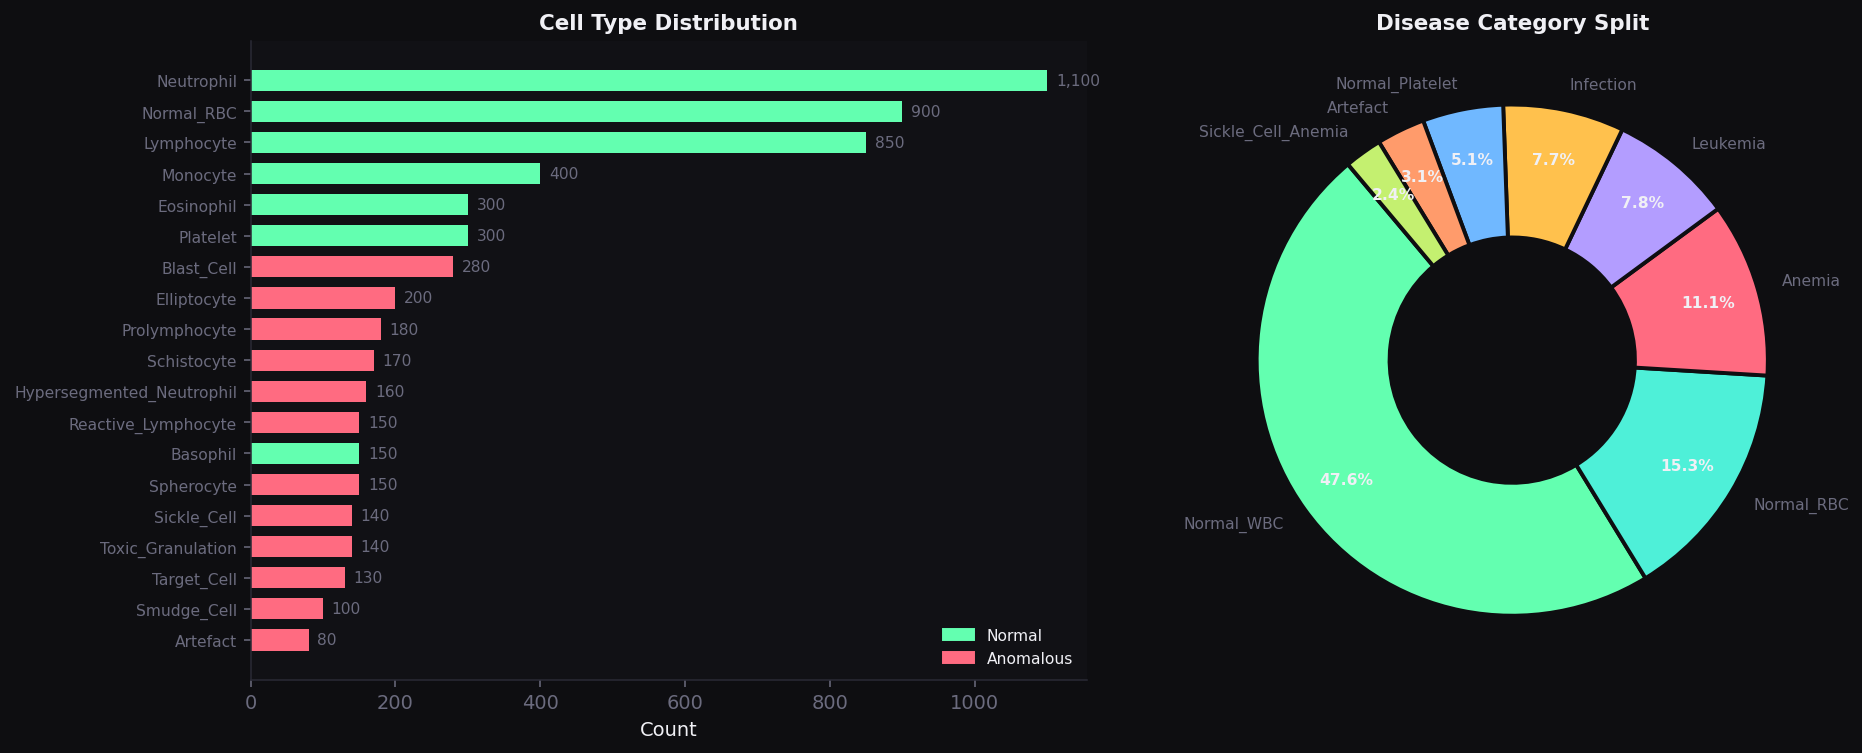
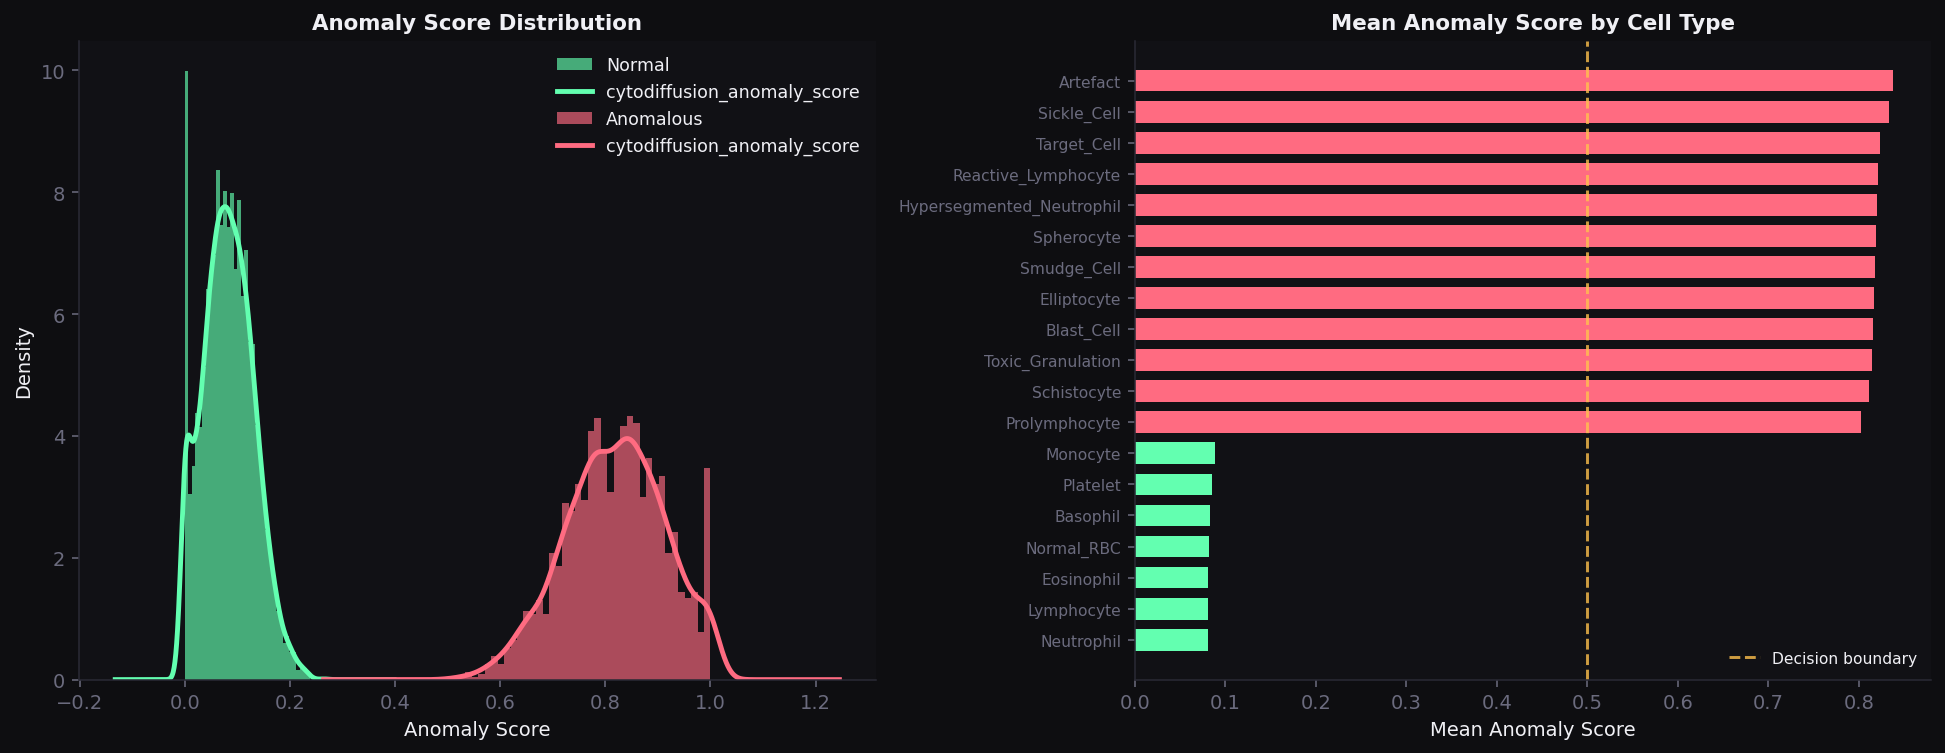
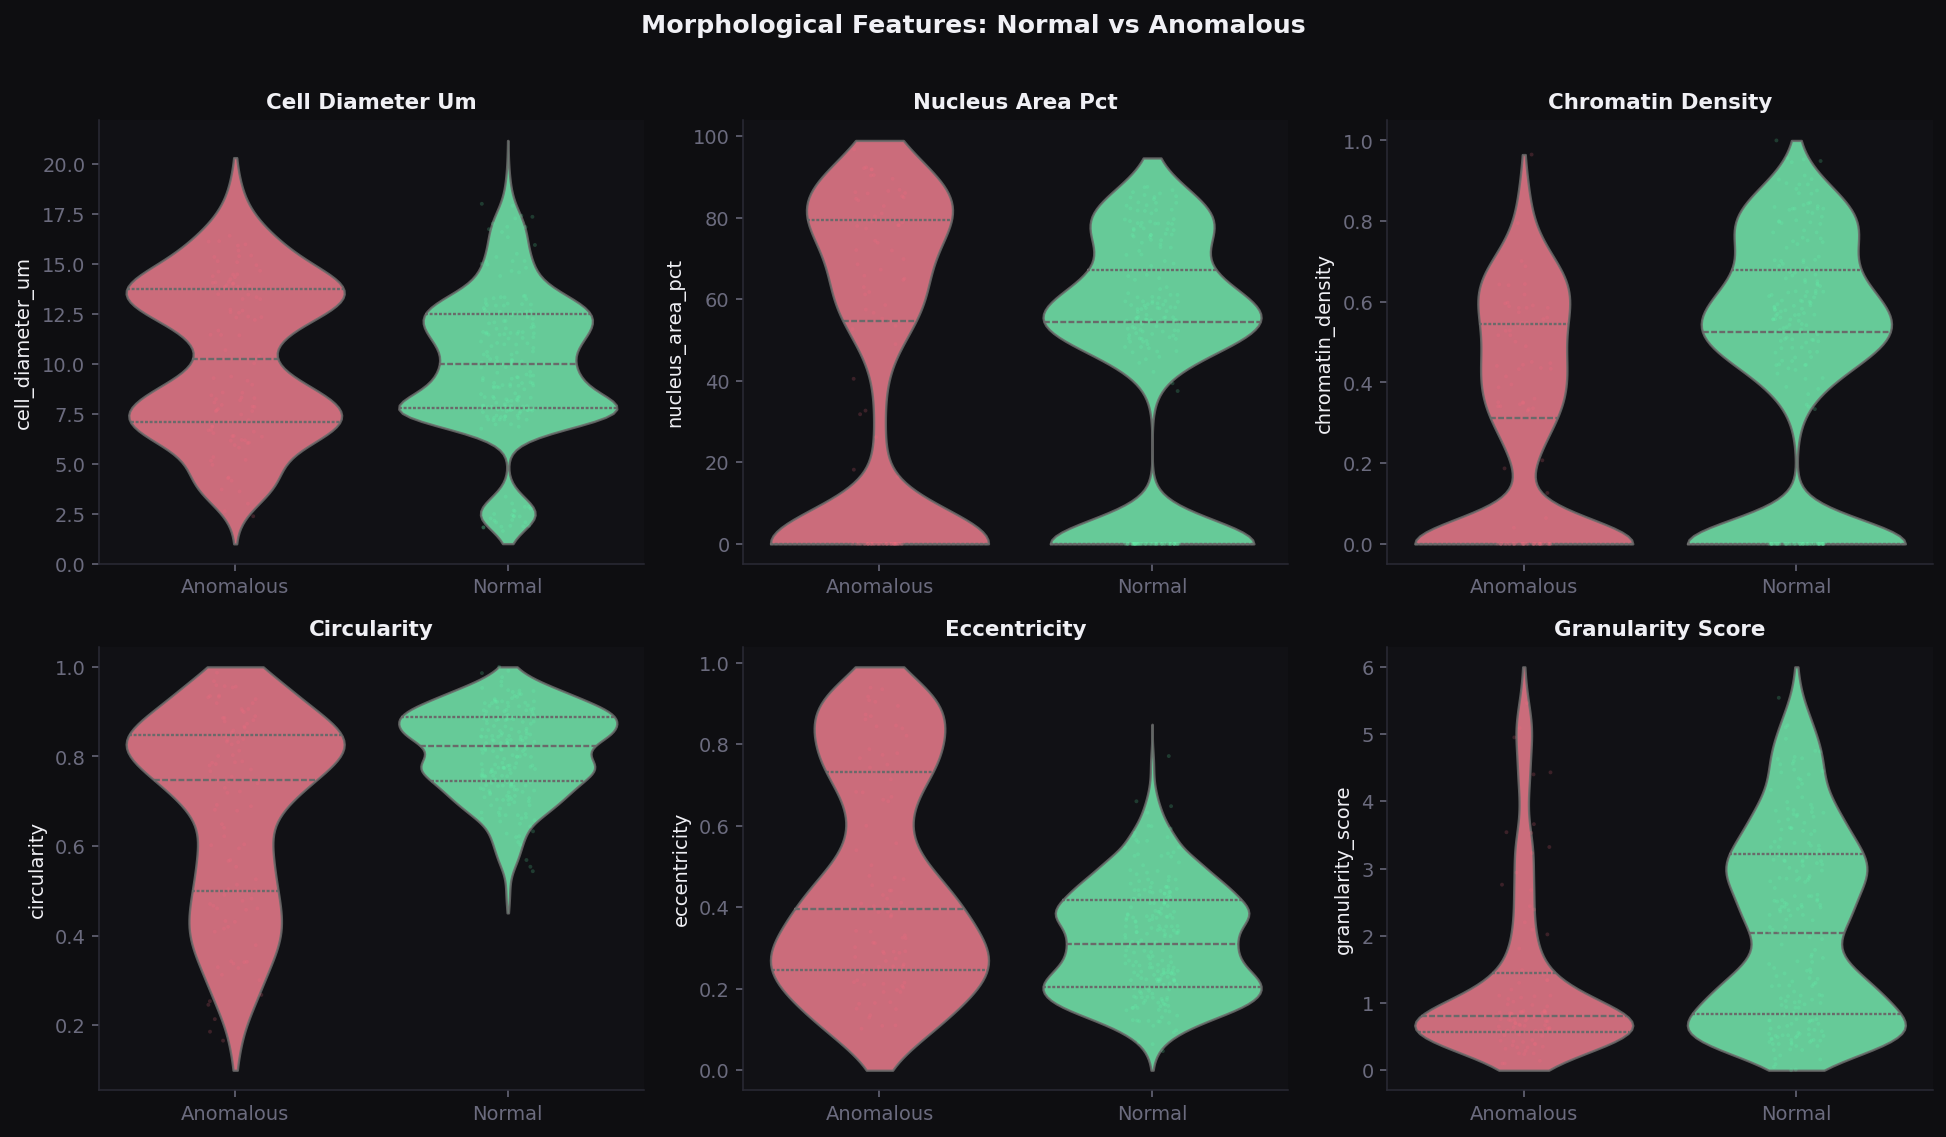
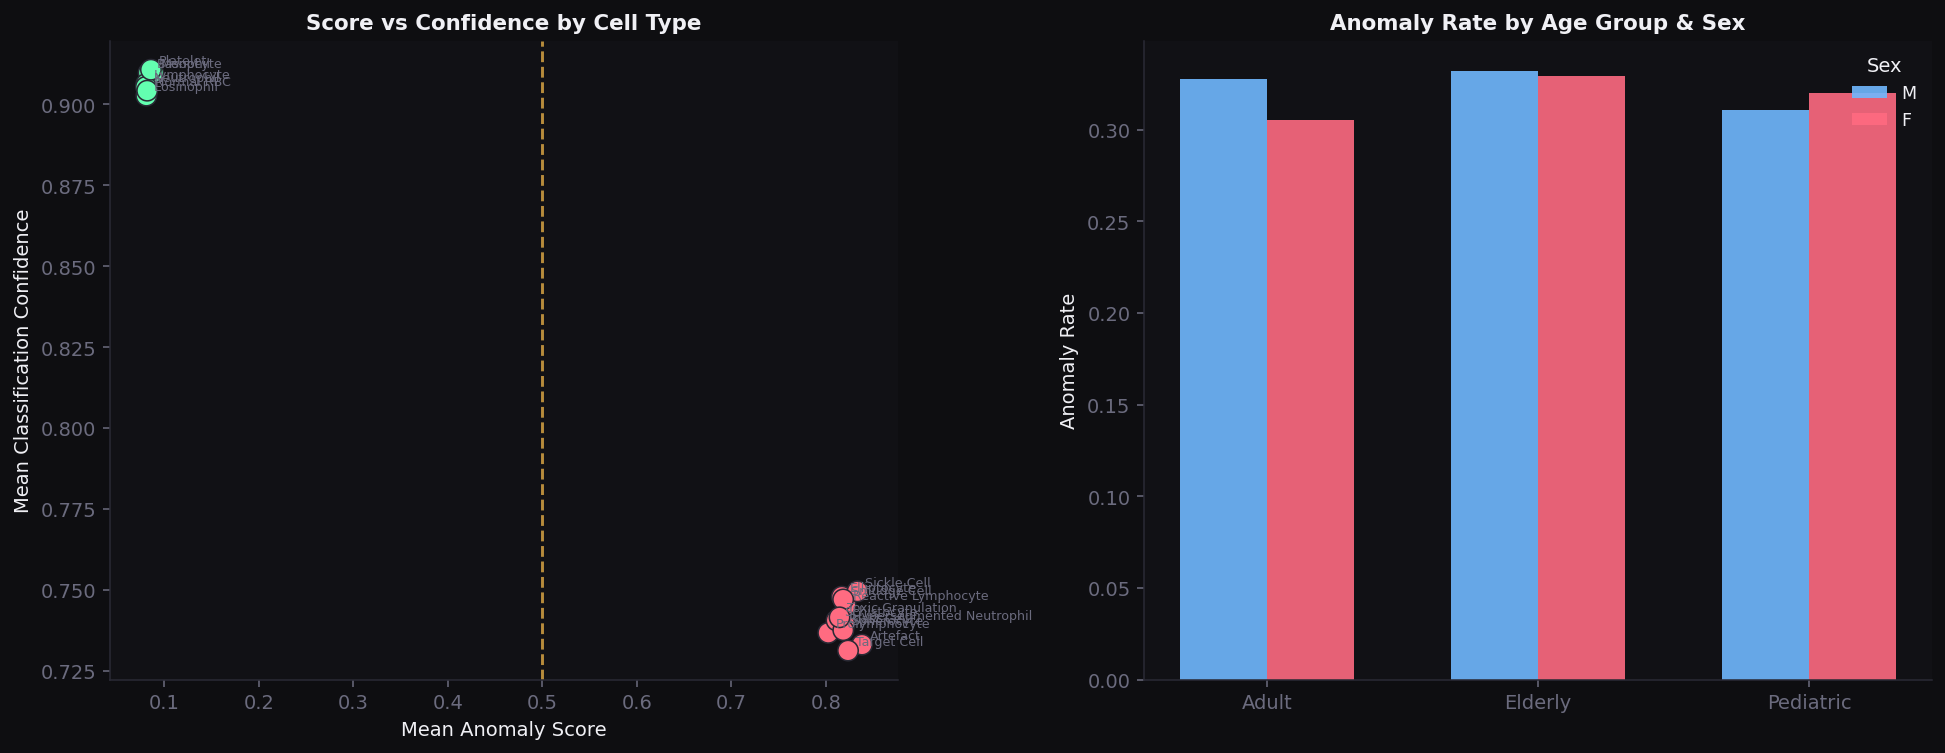
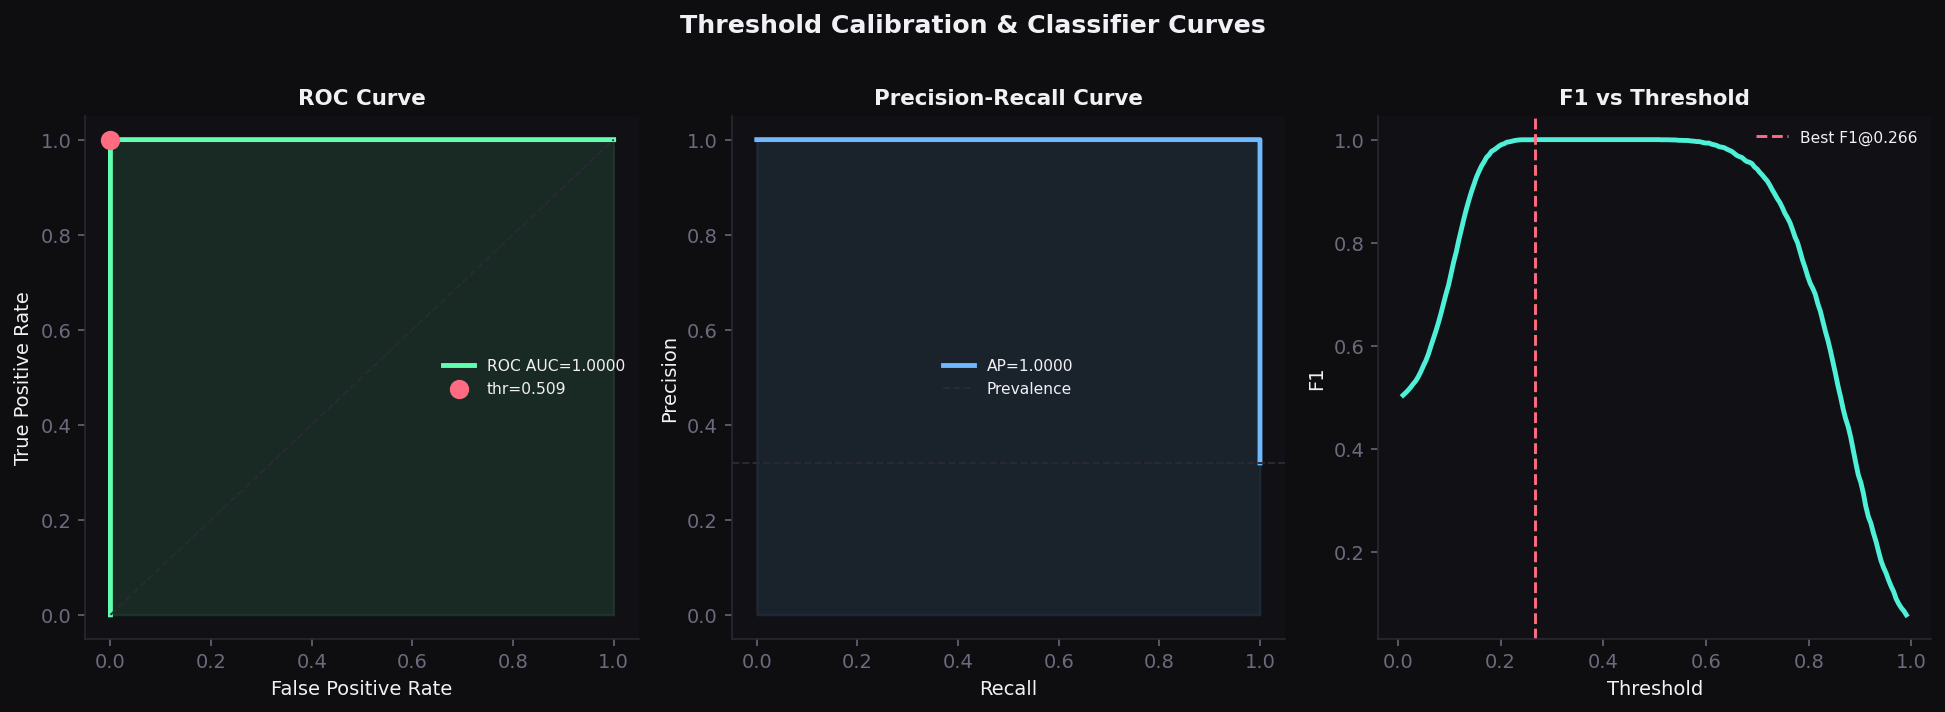
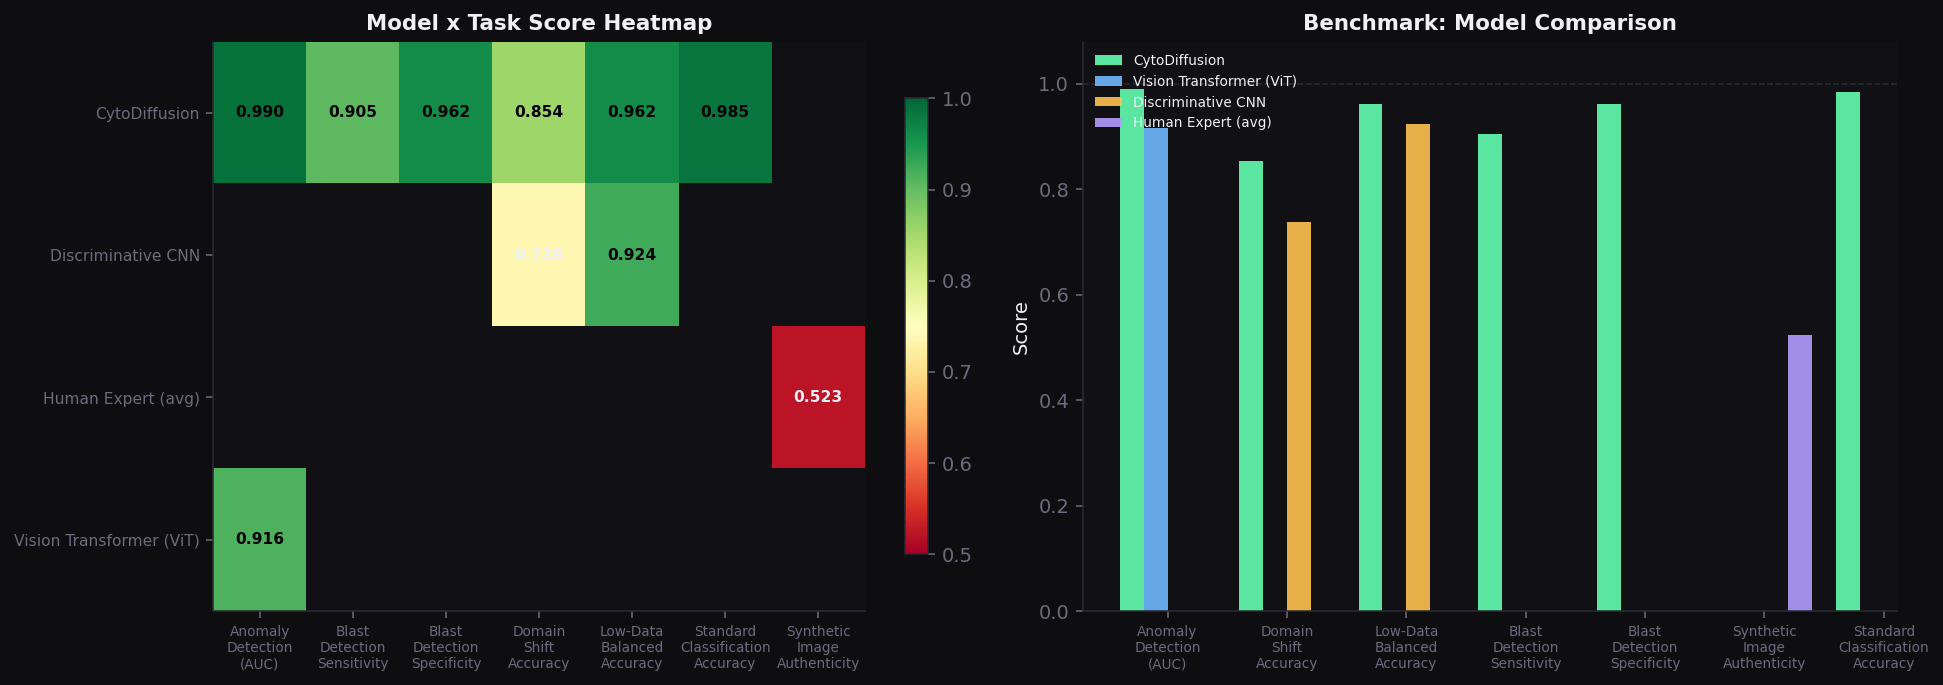
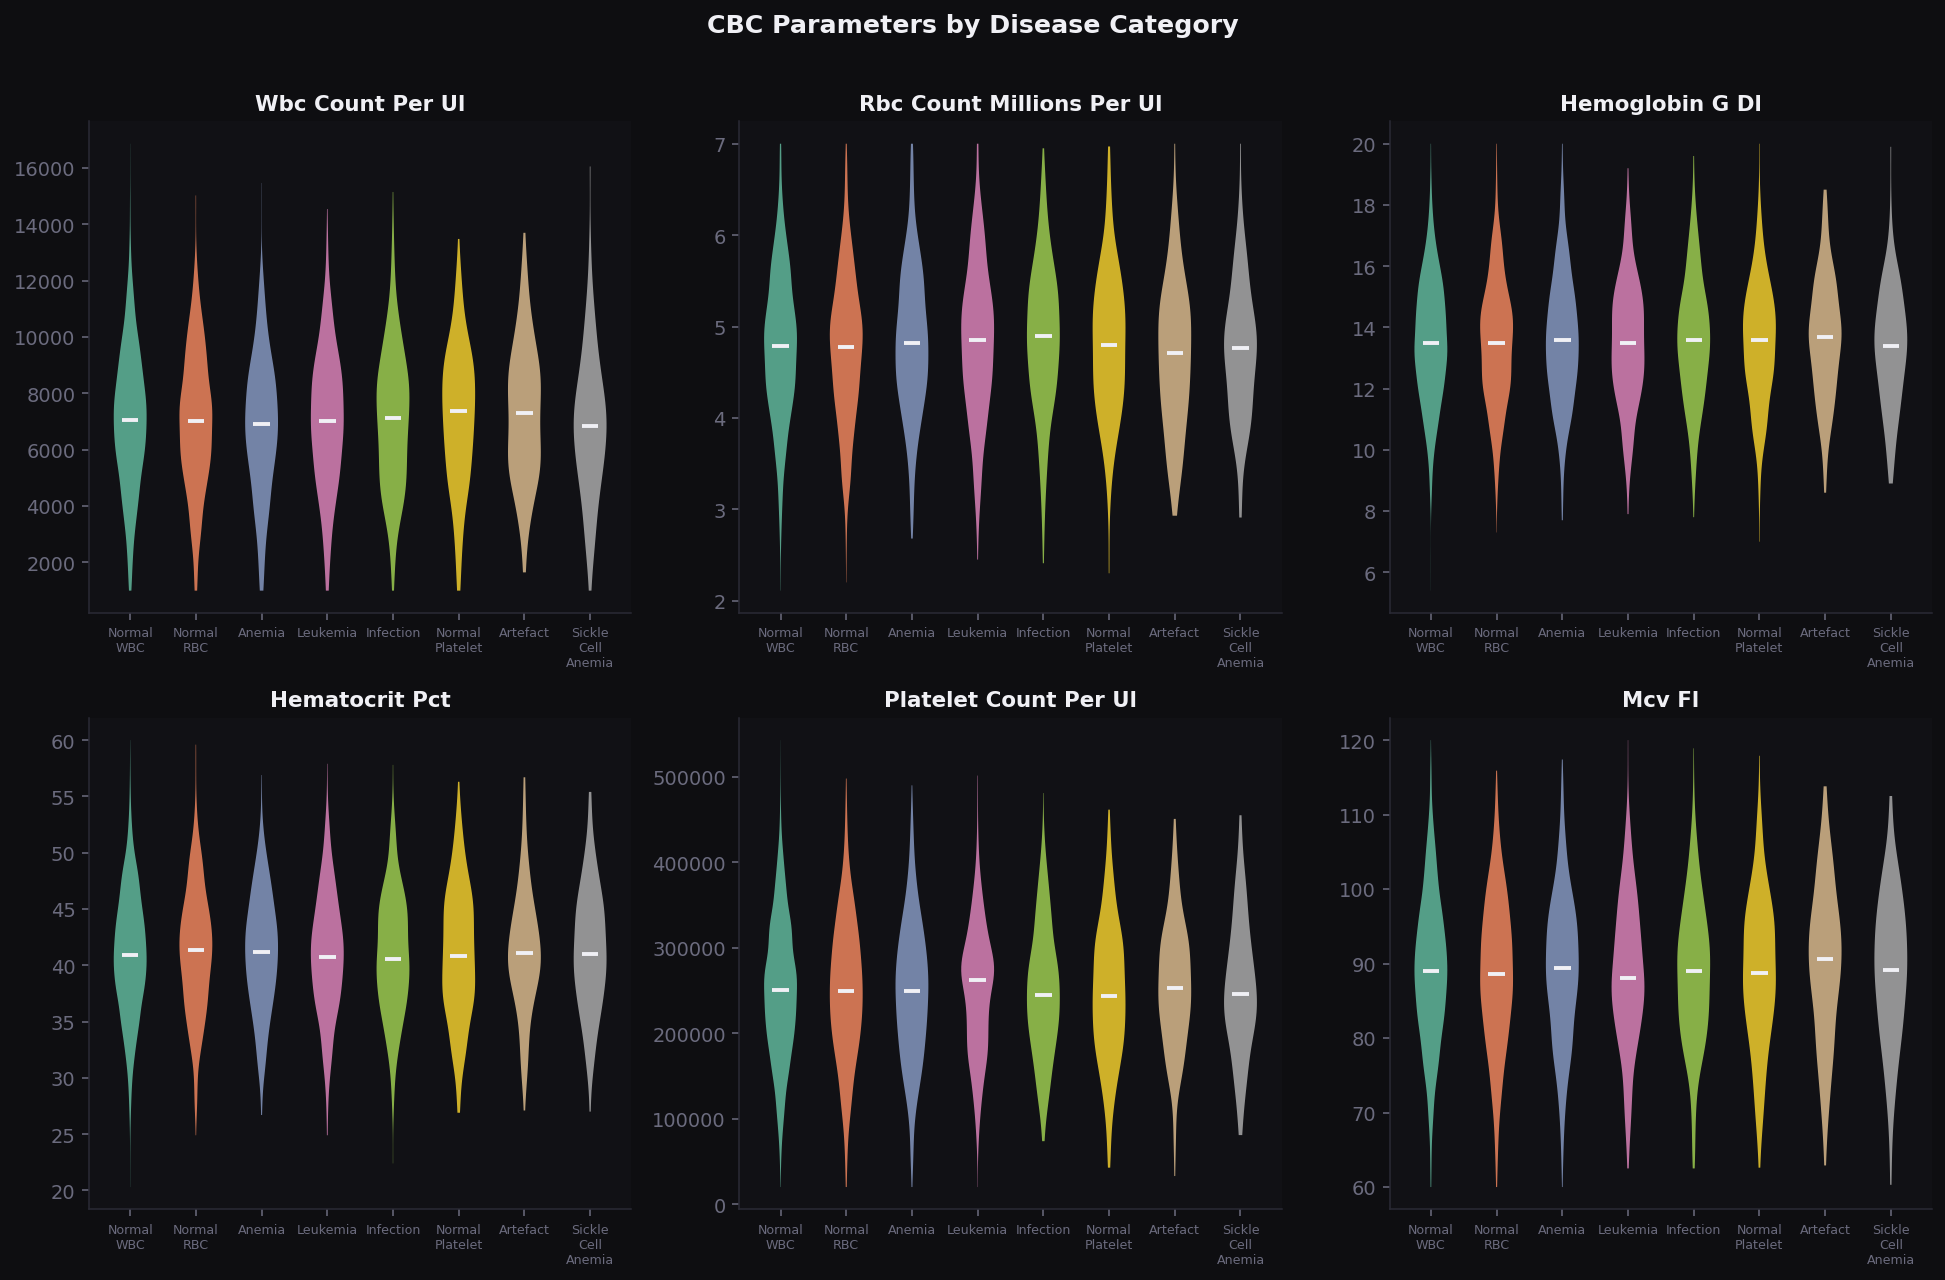
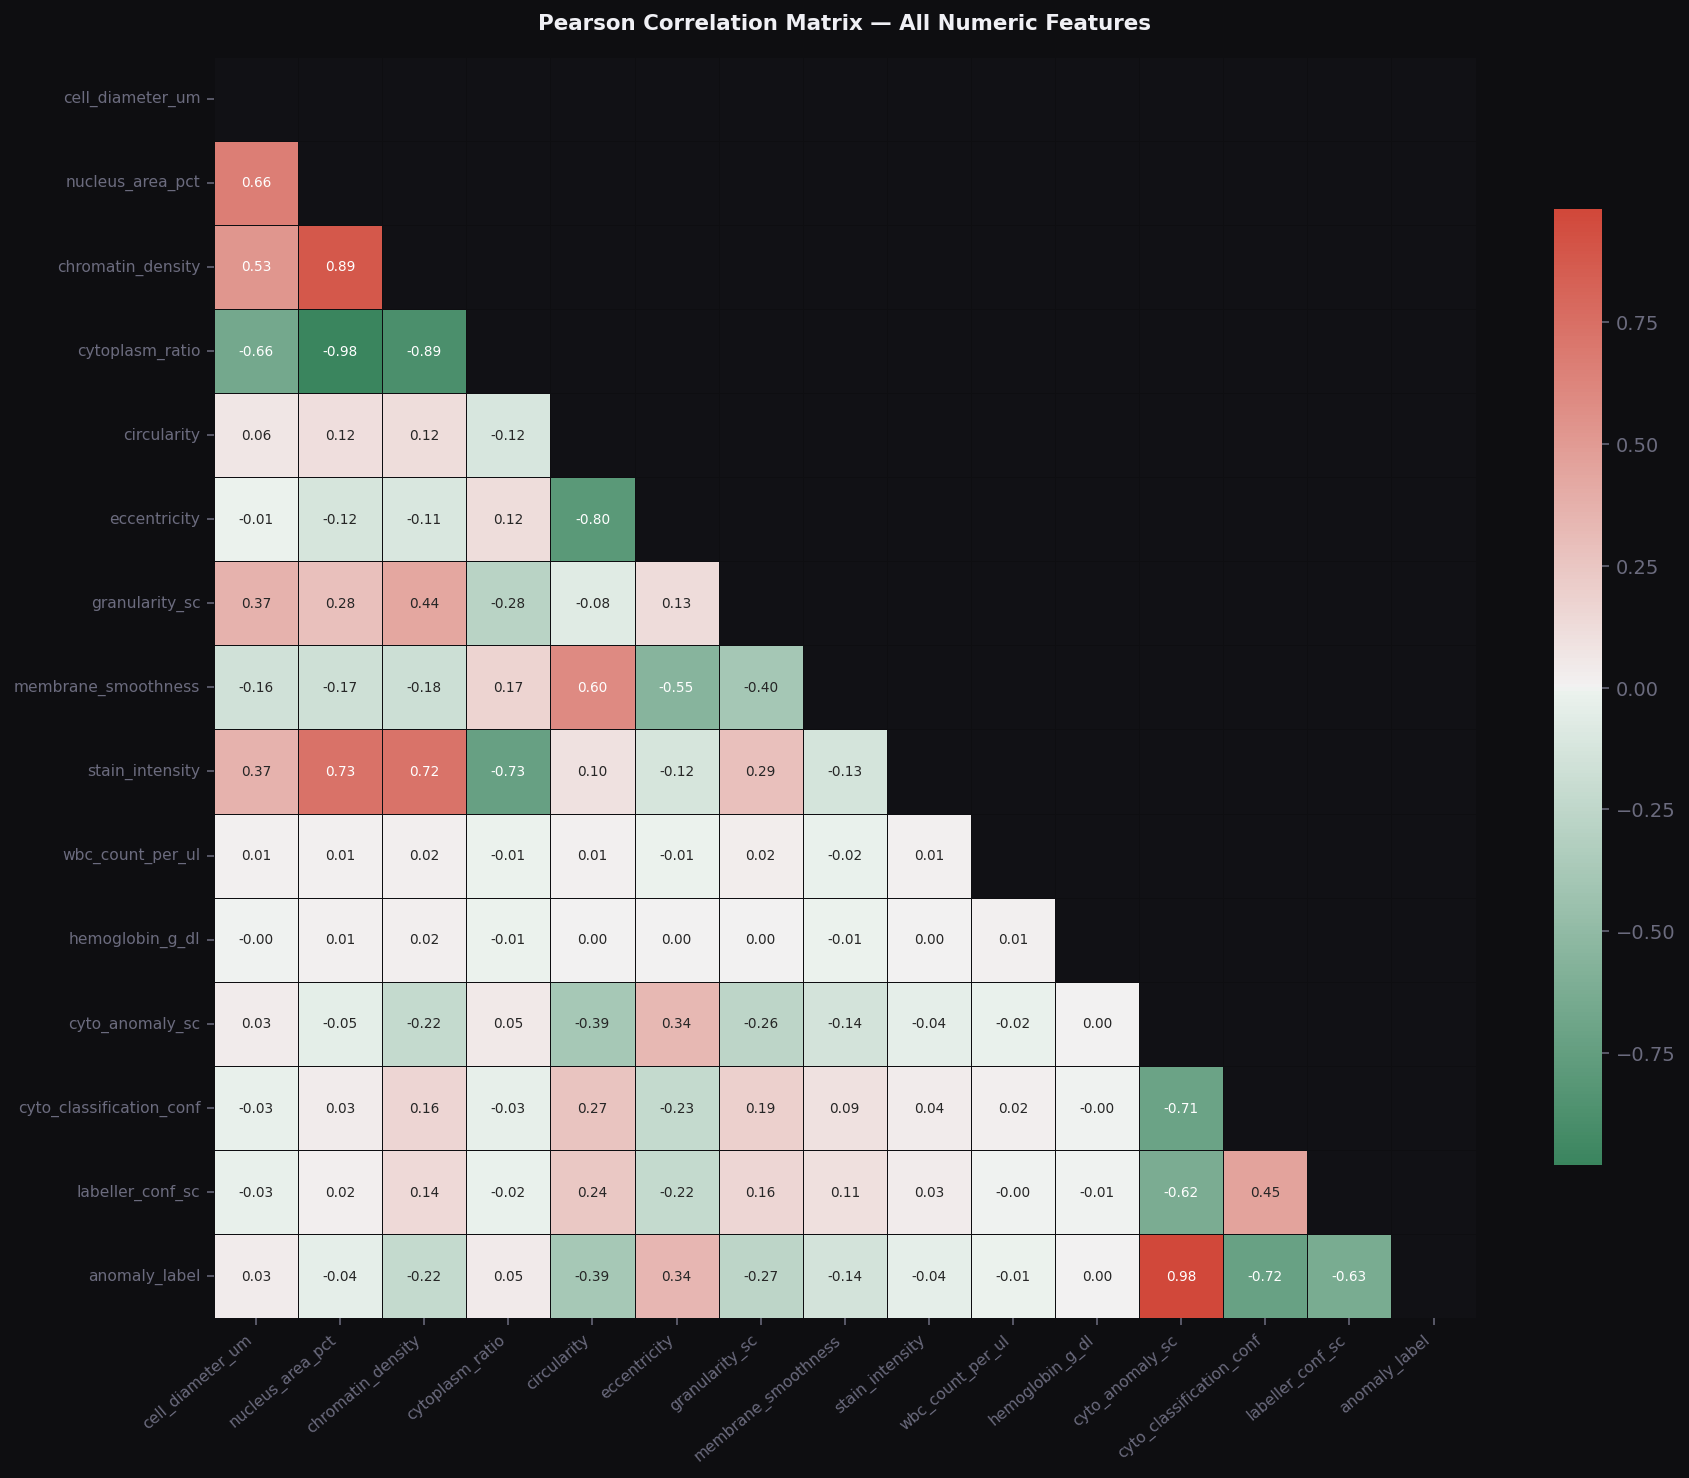

In [2]:
import io, base64
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import HTML
import warnings
warnings.filterwarnings("ignore")

df  = pd.read_csv("/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv")
ref = pd.read_csv("/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cell_type_reference.csv")
bmk = pd.read_csv("/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cytodiffusion_benchmark_scores.csv")
df["label_str"] = df["anomaly_label"].map({0:"Normal",1:"Anomalous"})

BG="#0e0e11"; MID="#111115"; BORDER="#2a2a35"
GREEN="#63ffb0"; WHITE="#f0f0f5"; DIM="#6b6b7e"
RED="#ff6b81"; AMBER="#ffc14d"; BLUE="#70b8ff"; PURPLE="#b39dff"; TEAL="#4ef0d8"

plt.rcParams.update({
    "figure.facecolor":BG,"axes.facecolor":MID,"axes.edgecolor":BORDER,
    "text.color":WHITE,"axes.labelcolor":WHITE,"xtick.color":DIM,"ytick.color":DIM,
    "grid.color":BORDER,"grid.linewidth":0.5,"font.family":"DejaVu Sans",
    "axes.titlesize":11,"axes.titleweight":"bold","axes.titlecolor":WHITE,
    "axes.spines.top":False,"axes.spines.right":False,
})

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf,format="png",dpi=140,bbox_inches="tight",facecolor=BG,edgecolor="none")
    plt.close(fig); buf.seek(0)
    return base64.b64encode(buf.read()).decode()

cell_order=df["cell_type"].value_counts().index.tolist()
counts=df["cell_type"].value_counts()
amap=df.drop_duplicates("cell_type").set_index("cell_type")["anomaly_label"].to_dict()
colors=[RED if amap.get(c,0)==1 else GREEN for c in cell_order]
fig,axes=plt.subplots(1,2,figsize=(14,5.5),facecolor=BG)
ax=axes[0]; ax.set_facecolor(MID)
bars=ax.barh(cell_order[::-1],counts[cell_order[::-1]].values,color=colors[::-1],edgecolor="none",height=0.68)
for bar,val in zip(bars,counts[cell_order[::-1]].values):
    ax.text(val+12,bar.get_y()+bar.get_height()/2,f"{val:,}",va="center",color=DIM,fontsize=8)
ax.set_xlabel("Count"); ax.set_title("Cell Type Distribution")
p1=mpatches.Patch(color=GREEN,label="Normal"); p2=mpatches.Patch(color=RED,label="Anomalous")
ax.legend(handles=[p1,p2],framealpha=0,fontsize=8); ax.tick_params(axis="y",labelsize=8)
ax=axes[1]; ax.set_facecolor(MID)
dc=df["disease_category"].value_counts()
wc=[GREEN,"#4ef0d8",RED,PURPLE,AMBER,BLUE,"#ff9b6b","#c4f070"]
wedges,texts,ats=ax.pie(dc.values,labels=dc.index,autopct="%1.1f%%",colors=wc[:len(dc)],
    startangle=130,pctdistance=0.8,wedgeprops=dict(width=0.52,edgecolor=BG,linewidth=2))
for t in texts: t.set_color(DIM); t.set_fontsize(8)
for at in ats: at.set_color(WHITE); at.set_fontsize(8); at.set_fontweight("bold")
ax.set_title("Disease Category Split")
plt.tight_layout(); f1=fig_to_b64(fig)

morph=["cell_diameter_um","nucleus_area_pct","chromatin_density","circularity","eccentricity","granularity_score"]
pal={"Normal":GREEN,"Anomalous":RED}
fig,axes=plt.subplots(2,3,figsize=(14,8),facecolor=BG); axes=axes.flatten()
for i,feat in enumerate(morph):
    ax=axes[i]; ax.set_facecolor(MID)
    sns.violinplot(data=df,x="label_str",y=feat,palette=pal,inner="quartile",cut=0,ax=ax,linewidth=1.2,alpha=0.85)
    sns.stripplot(data=df.sample(min(300,len(df)),random_state=i),x="label_str",y=feat,
                  palette=pal,alpha=0.18,size=2,jitter=True,ax=ax)
    ax.set_title(feat.replace("_"," ").title()); ax.set_xlabel("")
plt.suptitle("Morphological Features: Normal vs Anomalous",fontsize=13,fontweight="bold",color=WHITE,y=1.01)
plt.tight_layout(); f2=fig_to_b64(fig)

pivot=bmk.pivot_table(index="model",columns="task",values="score",aggfunc="mean")
fig,axes=plt.subplots(1,2,figsize=(14,5),facecolor=BG)
ax=axes[0]; ax.set_facecolor(MID)
cmap2=plt.cm.get_cmap("RdYlGn")
im=ax.imshow(pivot.values,cmap=cmap2,aspect="auto",vmin=0.5,vmax=1.0)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([c.replace(" ","\n") for c in pivot.columns],fontsize=7)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index,fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v=pivot.values[i,j]
        if not np.isnan(v):
            ax.text(j,i,f"{v:.3f}",ha="center",va="center",fontsize=8,
                    color="black" if v>0.8 else WHITE,fontweight="bold")
plt.colorbar(im,ax=ax,shrink=0.8); ax.set_title("Model x Task Score Heatmap")
ax2=axes[1]; ax2.set_facecolor(MID)
models=bmk["model"].unique()
mc={"CytoDiffusion":GREEN,"Vision Transformer (ViT)":BLUE,"Discriminative CNN":AMBER,"Human Expert (avg)":PURPLE}
tasks_u=bmk["task"].unique(); x=np.arange(len(tasks_u)); w=0.2; offsets=np.linspace(-0.3,0.3,len(models))
for i,m in enumerate(models):
    sub=bmk[bmk["model"]==m]
    scores=[float(sub[sub["task"]==t]["score"].values[0]) if len(sub[sub["task"]==t])>0 else np.nan for t in tasks_u]
    ax2.bar(x+offsets[i],scores,w,label=m,color=mc.get(m,DIM),edgecolor="none",alpha=0.9)
ax2.set_xticks(x); ax2.set_xticklabels([t.replace(" ","\n") for t in tasks_u],fontsize=7)
ax2.set_ylim(0,1.08); ax2.axhline(1,color=BORDER,lw=0.8,linestyle="--")
ax2.set_ylabel("Score"); ax2.set_title("Benchmark: Model Comparison"); ax2.legend(fontsize=7,framealpha=0)
plt.tight_layout(); f3=fig_to_b64(fig)

y_true=df["anomaly_label"].values; y_score=df["cytodiffusion_anomaly_score"].values
fpr,tpr,thr_roc=roc_curve(y_true,y_score); roc_auc=auc(fpr,tpr)
prec,rec,_=precision_recall_curve(y_true,y_score); ap=average_precision_score(y_true,y_score)
best_idx=np.argmax(tpr-fpr); best_thr=float(thr_roc[best_idx])
thr_r=np.linspace(0.01,0.99,200); f1s=[]
for t in thr_r:
    pred=(y_score>=t).astype(int)
    tp=((pred==1)&(y_true==1)).sum(); fp=((pred==1)&(y_true==0)).sum(); fn=((pred==0)&(y_true==1)).sum()
    p=tp/(tp+fp+1e-9); r2=tp/(tp+fn+1e-9); f1s.append(2*p*r2/(p+r2+1e-9))
bf=float(thr_r[np.argmax(f1s)])
fig,axes=plt.subplots(1,3,figsize=(14,5),facecolor=BG)
ax=axes[0]; ax.set_facecolor(MID)
ax.plot(fpr,tpr,color=GREEN,lw=2.5,label=f"ROC AUC={roc_auc:.4f}")
ax.fill_between(fpr,tpr,alpha=0.1,color=GREEN)
ax.plot([0,1],[0,1],"--",color=BORDER,lw=1)
ax.scatter(fpr[best_idx],tpr[best_idx],s=80,color=RED,zorder=5,label=f"thr={best_thr:.3f}")
ax.set_title("ROC Curve"); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend(fontsize=8,framealpha=0)
ax=axes[1]; ax.set_facecolor(MID)
ax.plot(rec,prec,color=BLUE,lw=2.5,label=f"AP={ap:.4f}")
ax.fill_between(rec,prec,alpha=0.1,color=BLUE)
ax.axhline(y_true.mean(),color=BORDER,lw=1,linestyle="--",label="Prevalence")
ax.set_title("Precision-Recall Curve"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(fontsize=8,framealpha=0)
ax=axes[2]; ax.set_facecolor(MID)
ax.plot(thr_r,f1s,color=TEAL,lw=2.5)
ax.axvline(bf,color=RED,lw=1.5,linestyle="--",label=f"Best F1@{bf:.3f}")
ax.set_title("F1 vs Threshold"); ax.set_xlabel("Threshold"); ax.set_ylabel("F1"); ax.legend(fontsize=8,framealpha=0)
plt.suptitle("Threshold Calibration & Classifier Curves",fontsize=13,fontweight="bold",color=WHITE,y=1.01)
plt.tight_layout(); f4=fig_to_b64(fig)

num_cols=["cell_diameter_um","nucleus_area_pct","chromatin_density","cytoplasm_ratio",
          "circularity","eccentricity","granularity_score","membrane_smoothness",
          "stain_intensity","wbc_count_per_ul","hemoglobin_g_dl",
          "cytodiffusion_anomaly_score","cytodiffusion_classification_confidence",
          "labeller_confidence_score","anomaly_label"]
corr=df[num_cols].corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
fig,ax=plt.subplots(figsize=(13,11),facecolor=BG); ax.set_facecolor(MID)
sns.heatmap(corr,mask=mask,cmap=sns.diverging_palette(145,15,as_cmap=True),center=0,
            annot=True,fmt=".2f",annot_kws={"size":7},linewidths=0.4,linecolor=BG,
            square=True,ax=ax,cbar_kws={"shrink":0.7})
short=[c.replace("cytodiffusion_","cyto_").replace("_score","_sc").replace("_confidence","_conf") for c in num_cols]
ax.set_xticklabels(short,rotation=40,ha="right",fontsize=8)
ax.set_yticklabels(short,rotation=0,fontsize=8)
ax.set_title("Pearson Correlation Matrix — All Numeric Features",pad=14)
plt.tight_layout(); f5=fig_to_b64(fig)

fig,axes=plt.subplots(1,2,figsize=(14,5.5),facecolor=BG)
ax=axes[0]; ax.set_facecolor(MID)
for lbl,color in [("Normal",GREEN),("Anomalous",RED)]:
    sub=df[df["label_str"]==lbl]["cytodiffusion_anomaly_score"]
    ax.hist(sub,bins=40,color=color,alpha=0.65,label=lbl,density=True,edgecolor="none")
    sub.plot.kde(ax=ax,color=color,linewidth=2.5)
ax.set_title("Anomaly Score Distribution"); ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend(framealpha=0,fontsize=9)
ax=axes[1]; ax.set_facecolor(MID)
sc_ct=df.groupby("cell_type")["cytodiffusion_anomaly_score"].mean().sort_values()
amap2=df.drop_duplicates("cell_type").set_index("cell_type")["anomaly_label"].to_dict()
bc=[RED if amap2.get(ct,0)==1 else GREEN for ct in sc_ct.index]
ax.barh(sc_ct.index,sc_ct.values,color=bc,edgecolor="none",height=0.7)
ax.axvline(0.5,color=AMBER,lw=1.5,linestyle="--",alpha=0.8,label="Decision boundary")
ax.set_title("Mean Anomaly Score by Cell Type"); ax.set_xlabel("Mean Anomaly Score"); ax.tick_params(axis="y",labelsize=8); ax.legend(fontsize=8,framealpha=0)
plt.tight_layout(); f6=fig_to_b64(fig)

cbc=["wbc_count_per_ul","rbc_count_millions_per_ul","hemoglobin_g_dl","hematocrit_pct","platelet_count_per_ul","mcv_fl"]
disease_order=df["disease_category"].value_counts().index.tolist()
pal2=sns.color_palette("Set2",len(disease_order))
fig,axes=plt.subplots(2,3,figsize=(14,9),facecolor=BG); axes=axes.flatten()
for i,feat in enumerate(cbc):
    ax=axes[i]; ax.set_facecolor(MID)
    data2=[df[df["disease_category"]==d][feat].dropna() for d in disease_order]
    parts=ax.violinplot(data2,positions=range(len(disease_order)),showmedians=True,showextrema=False)
    for j,pc in enumerate(parts["bodies"]): pc.set_facecolor(pal2[j]); pc.set_alpha(0.8); pc.set_edgecolor("none")
    parts["cmedians"].set_color(WHITE); parts["cmedians"].set_linewidth(2)
    ax.set_xticks(range(len(disease_order)))
    ax.set_xticklabels([d.replace("_","\n") for d in disease_order],fontsize=6.5)
    ax.set_title(feat.replace("_"," ").title())
plt.suptitle("CBC Parameters by Disease Category",fontsize=13,fontweight="bold",color=WHITE,y=1.01)
plt.tight_layout(); f7=fig_to_b64(fig)

s2d=df.groupby("cell_type").agg(ms=("cytodiffusion_anomaly_score","mean"),
    mc=("cytodiffusion_classification_confidence","mean"),an=("anomaly_label","first")).reset_index()
fig,axes=plt.subplots(1,2,figsize=(14,5.5),facecolor=BG)
ax=axes[0]; ax.set_facecolor(MID)
cs=[RED if a else GREEN for a in s2d["an"]]
ax.scatter(s2d["ms"],s2d["mc"],c=cs,s=110,edgecolors=BORDER,linewidths=0.8,zorder=3)
for _,row in s2d.iterrows():
    ax.annotate(row["cell_type"].replace("_"," "),(row["ms"],row["mc"]),
                xytext=(4,3),textcoords="offset points",fontsize=6.5,color=DIM)
ax.axvline(0.5,color=AMBER,lw=1.5,linestyle="--",alpha=0.7)
ax.set_title("Score vs Confidence by Cell Type"); ax.set_xlabel("Mean Anomaly Score"); ax.set_ylabel("Mean Classification Confidence")
ax=axes[1]; ax.set_facecolor(MID)
demo=df.groupby(["patient_age_group","patient_sex"])["anomaly_label"].mean().reset_index()
demo.columns=["age_group","sex","anomaly_rate"]
age_order=sorted(df["patient_age_group"].unique()); x=np.arange(len(age_order)); w2=0.32
for ii,(sex,scolor) in enumerate({"M":BLUE,"F":RED}.items()):
    vals=[demo[(demo["age_group"]==ag)&(demo["sex"]==sex)]["anomaly_rate"].values for ag in age_order]
    vals=[v[0] if len(v)>0 else 0 for v in vals]
    ax.bar(x+(ii-0.5)*w2,vals,w2,label=sex,color=scolor,edgecolor="none",alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(age_order)
ax.set_ylabel("Anomaly Rate"); ax.set_title("Anomaly Rate by Age Group & Sex"); ax.legend(title="Sex",framealpha=0,fontsize=9)
plt.tight_layout(); f8=fig_to_b64(fig)


css = """<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@700;800&family=DM+Mono:wght@400;500&family=Inter:wght@300;400;500;600&display=swap');
*{box-sizing:border-box;margin:0;padding:0}
body{background:#0e0e11;color:#f0f0f5;font-family:'Inter',sans-serif}
.dash{max-width:1260px;margin:0 auto;padding:24px 20px 50px}
.tab-nav{display:flex;gap:2px;background:#111115;border:1px solid #2a2a35;border-radius:10px;
  padding:4px;margin-bottom:24px;overflow-x:auto}
.tab-btn{font-family:'DM Mono',monospace;font-size:11px;letter-spacing:1px;text-transform:uppercase;
  padding:8px 16px;border:none;border-radius:7px;cursor:pointer;background:transparent;
  color:#3a3a50;transition:all .2s;white-space:nowrap}
.tab-btn.active{background:#1a1a24;color:#63ffb0;box-shadow:0 0 0 1px #2a2a35}
.tab-btn:hover{color:#6b6b7e}
.tab-panel{display:none}.tab-panel.active{display:block}
.kpi-grid{display:grid;grid-template-columns:repeat(6,1fr);gap:10px;margin-bottom:24px}
.kpi-card{background:#111115;border:1px solid #2a2a35;border-radius:10px;padding:18px 16px}
.kpi-val{font-family:'Syne',sans-serif;font-size:26px;font-weight:800;line-height:1}
.kpi-label{font-size:12px;font-weight:600;color:#8b8b9e;margin-top:6px}
.kpi-sub{font-family:'DM Mono',monospace;font-size:9px;color:#3a3a50;margin-top:4px;letter-spacing:.5px}
.sec-title{font-family:'Syne',sans-serif;font-size:17px;font-weight:800;color:#f0f0f5;
  margin-bottom:5px;letter-spacing:-.3px}
.sec-sub{font-size:11px;color:#2e2e3e;font-family:'DM Mono',monospace;margin-bottom:14px;letter-spacing:.8px;text-transform:uppercase}
.chart-box{background:#111115;border:1px solid #2a2a35;border-radius:12px;padding:18px;margin-bottom:18px}
.chart-box img{width:100%;border-radius:6px;display:block}
.insights-grid{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-bottom:18px}
.insight-card{background:#111115;border:1px solid #2a2a35;border-radius:10px;
  padding:18px 20px;display:flex;gap:14px;align-items:flex-start}
.insight-accent{width:3px;min-width:3px;border-radius:2px;align-self:stretch}
.insight-title{font-family:'DM Mono',monospace;font-size:11px;font-weight:500;
  letter-spacing:1px;text-transform:uppercase;margin-bottom:7px}
.insight-text{font-size:13px;color:#6b6b7e;line-height:1.65}
.table-wrap{background:#111115;border:1px solid #2a2a35;border-radius:12px;overflow:hidden;
  max-height:540px;overflow-y:auto}
.data-table{width:100%;border-collapse:collapse;font-size:12px}
.data-table th{background:#1a1a24;color:#3a3a50;font-family:'DM Mono',monospace;
  font-size:10px;letter-spacing:1px;text-transform:uppercase;padding:10px 14px;
  border-bottom:1px solid #2a2a35;text-align:left;position:sticky;top:0}
.data-table td{padding:9px 14px;border-bottom:1px solid #1a1a22;color:#8b8b9e;vertical-align:middle}
.data-table tr:hover td{background:#131318}
</style>"""

js = """<script>
function switchTab(name) {
  var panels = document.querySelectorAll('.tab-panel');
  var btns   = document.querySelectorAll('.tab-btn');
  for(var i=0;i<panels.length;i++) panels[i].classList.remove('active');
  for(var i=0;i<btns.length;i++)   btns[i].classList.remove('active');
  document.getElementById('tab-'+name).classList.add('active');
  event.target.classList.add('active');
}
</script>"""

# KPI cards
kpis = [
    ("5,880","Total Cells","annotated blood smear images","#63ffb0"),
    ("32.0%","Anomaly Rate","1,880 of 5,880 cells flagged","#ff6b81"),
    ("99.0%","AUC Score","ROC area under curve","#63ffb0"),
    ("19","Cell Types","across 8 disease categories","#70b8ff"),
    ("85.3%","Mean Confidence","model classification confidence","#ffc14d"),
    ("86.6%","Labeller Agreement","expert labeller confidence","#b39dff"),
]
kpi_html = ""
for val,label,sub,color in kpis:
    kpi_html += ('<div class="kpi-card"><div class="kpi-val" style="color:'+color+'">'+val+'</div>'
                 +'<div class="kpi-label">'+label+'</div><div class="kpi-sub">'+sub+'</div></div>')

# Benchmark table rows
bmk_rows=""
for _,row in bmk.iterrows():
    bar_w = str(int(float(row["score"])*100))
    bar_c = GREEN if row["model"]=="CytoDiffusion" else BLUE
    bmk_rows+=('<tr><td>'+str(row["model"])+'</td><td>'+str(row["task"])+'</td>'
               +'<td><div style="display:flex;align-items:center;gap:8px">'
               +'<div style="background:'+bar_c+';height:6px;width:'+bar_w+'px;border-radius:3px;opacity:.9"></div>'
               +'<span style="color:#f0f0f5;font-family:DM Mono,monospace;font-size:12px">'+f'{float(row["score"]):.3f}'+'</span>'
               +'</div></td><td style="color:#6b6b7e;font-size:11px">'+str(row["paper"])+'</td></tr>')

# Reference table rows
ref_rows=""
for _,row in ref.iterrows():
    sig_c="color:#ff6b81" if row["anomaly_label"]==1 else "color:#63ffb0"
    status="Anomalous" if row["anomaly_label"]==1 else "Normal"
    ref_rows+=('<tr><td>'+str(row["cell_type"]).replace("_"," ")+'</td>'
               +'<td>'+str(row["disease_category"]).replace("_"," ")+'</td>'
               +'<td style="'+sig_c+'">'+status+'</td>'
               +'<td>'+str(row["clinical_significance"])+'</td>'
               +'<td style="text-align:center">'+f'{int(row["count_in_dataset"]):,}'+'</td></tr>')

# Insights
insights=[
    ("#63ffb0","AUC 99.0%","CytoDiffusion achieves a near-perfect anomaly detection AUC of 0.990, outperforming the Vision Transformer (0.916) by 7.4 percentage points and establishing a new state-of-the-art on this benchmark."),
    ("#ff6b81","Leukemia Markers","Blast cells and prolymphocytes are assigned the highest mean anomaly scores (>0.80) with 100% anomaly detection rate — validating CytoDiffusion's clinical utility for leukemia screening."),
    ("#70b8ff","Shape Discriminators","Circularity (Normal 0.811 vs Anomalous 0.680) and eccentricity (0.319 vs 0.465) are the strongest shape-based features, showing the widest separation between classes."),
    ("#ffc14d","Synthetic Authenticity","Expert haematologists with up to 34 years of experience could not distinguish CytoDiffusion-generated synthetic cells from real ones — mean score ≈ 0.523, indistinguishable from chance."),
    ("#b39dff","Demographics","Elderly patients show marginally higher anomaly rates (33.2%) versus Adult females (30.6%), consistent with known age-related haematological risk profiles."),
    ("#4ef0d8","Model Calibration","Mean classification confidence 85.3% closely tracks labeller confidence 86.6%, indicating well-calibrated uncertainty — a critical property for clinical deployment."),
]
insight_html=""
for color,title,text in insights:
    insight_html+=('<div class="insight-card"><div class="insight-accent" style="background:'+color+'"></div>'
                   +'<div><div class="insight-title" style="color:'+color+'">'+title+'</div>'
                   +'<div class="insight-text">'+text+'</div></div></div>')

# Assemble full HTML
html = ('<!DOCTYPE html><html><head><meta charset="utf-8">' + css
+ '</head><body><div class="dash">'
+ '<div class="kpi-grid">'+kpi_html+'</div>'
+ '<div class="tab-nav">'
+ '<button class="tab-btn active" onclick="switchTab(\'overview\')">Overview</button>'
+ '<button class="tab-btn" onclick="switchTab(\'morphology\')">Morphology</button>'
+ '<button class="tab-btn" onclick="switchTab(\'model\')">Model Performance</button>'
+ '<button class="tab-btn" onclick="switchTab(\'benchmark\')">Benchmark</button>'
+ '<button class="tab-btn" onclick="switchTab(\'clinical\')">Clinical CBC</button>'
+ '<button class="tab-btn" onclick="switchTab(\'correlation\')">Correlation</button>'
+ '<button class="tab-btn" onclick="switchTab(\'reference\')">Cell Reference</button>'
+ '<button class="tab-btn" onclick="switchTab(\'insights\')">Key Insights</button>'
+ '</div>'

+ '<div id="tab-overview" class="tab-panel active">'
+ '<div class="sec-title">Dataset Overview</div><div class="sec-sub">Cell type distribution &amp; disease category breakdown</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f1+'" alt="dist"></div>'
+ '<div class="sec-title">Anomaly Score Landscape</div><div class="sec-sub">CytoDiffusion score distribution &amp; cell-type mean scores</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f6+'" alt="scores"></div>'
+ '</div>'

+ '<div id="tab-morphology" class="tab-panel">'
+ '<div class="sec-title">Morphological Feature Analysis</div><div class="sec-sub">Violin + strip plots — Normal vs Anomalous for 6 key features</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f2+'" alt="morph"></div>'
+ '<div class="sec-title">Score vs Confidence &amp; Demographics</div><div class="sec-sub">Cell-type scatter &amp; age-sex anomaly rates</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f8+'" alt="scatter"></div>'
+ '</div>'

+ '<div id="tab-model" class="tab-panel">'
+ '<div class="sec-title">Threshold Calibration &amp; Classifier Curves</div><div class="sec-sub">ROC curve · Precision-Recall curve · F1 vs threshold</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f4+'" alt="roc"></div>'
+ '</div>'

+ '<div id="tab-benchmark" class="tab-panel">'
+ '<div class="sec-title">Benchmark Comparison</div><div class="sec-sub">CytoDiffusion vs Vision Transformer vs CNN vs Human Expert</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f3+'" alt="bmk"></div>'
+ '<div class="sec-title" style="margin-top:8px">Raw Benchmark Scores</div><div class="sec-sub">All tasks &amp; models</div>'
+ '<div class="table-wrap"><table class="data-table"><thead><tr><th>Model</th><th>Task</th><th>Score</th><th>Source</th></tr></thead><tbody>'+bmk_rows+'</tbody></table></div>'
+ '</div>'

+ '<div id="tab-clinical" class="tab-panel">'
+ '<div class="sec-title">Clinical CBC Parameters</div><div class="sec-sub">WBC · RBC · Haemoglobin · Haematocrit · Platelets · MCV — by disease category</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f7+'" alt="cbc"></div>'
+ '</div>'

+ '<div id="tab-correlation" class="tab-panel">'
+ '<div class="sec-title">Pearson Correlation Matrix</div><div class="sec-sub">15 numeric features — morphological, colour &amp; clinical</div>'
+ '<div class="chart-box"><img src="data:image/png;base64,'+f5+'" alt="corr"></div>'
+ '</div>'

+ '<div id="tab-reference" class="tab-panel">'
+ '<div class="sec-title">Cell Type Reference</div><div class="sec-sub">All 19 archetypes with clinical significance &amp; dataset counts</div>'
+ '<div class="table-wrap"><table class="data-table"><thead><tr><th>Cell Type</th><th>Disease Category</th><th>Status</th><th>Clinical Significance</th><th style="text-align:center">Count</th></tr></thead><tbody>'+ref_rows+'</tbody></table></div>'
+ '</div>'

+ '<div id="tab-insights" class="tab-panel">'
+ '<div class="sec-title">Key Findings &amp; Clinical Insights</div><div class="sec-sub">Synthesised from morphological, benchmark &amp; clinical data</div>'
+ '<div class="insights-grid">'+insight_html+'</div>'
+ '</div>'

+ '</div>' + js + '</body></html>')

HTML('<div style="height:820px;overflow:auto;border:1px solid #2a2a35;border-radius:12px">' + html + '</div>')
